# Netflix Content Catalog Analysis

**Objective:** Explore what the Netflix catalog contains and how it has
evolved - the content mix, growth trajectory, geographic sources, genres,
and target audiences.

**Dataset:** Netflix Movies and TV Shows (Kaggle) - ~8,800 titles with type,
country, date added, rating, duration, and genre information.

**Tools:** Python, pandas, matplotlib

**Questions I set out to answer:**
1. What is the split between Movies and TV Shows?
2. How fast has the catalog grown?
3. Which countries produce Netflix content?
4. Which genres dominate?
5. Who is the content aimed at (ratings mix)?
6. How long is typical content (movie runtimes, TV seasons)?

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

print(f"Dataset shape: {df.shape[0]} titles, {df.shape[1]} columns")
df.head()

Dataset shape: 8807 titles, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Data Cleaning

Real catalog data has gaps: many titles are missing a director, some are
missing country or date information. I quantify the gaps first, then parse
the `date_added` column (stored as text like "September 25, 2021", sometimes
with stray spaces) into a proper date.

In [2]:
# Quantify missing values before deciding how to handle them.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

pd.DataFrame({"missing": missing, "percent": missing_pct}).query("missing > 0")

,missing,percent
director,2634,29.9
cast,825,9.4
country,831,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0


In [3]:
# Parse date_added: strip stray spaces first, then convert.
# errors="coerce" turns unparseable values into NaT instead of crashing.
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year

print("Successfully parsed dates:", df["date_added"].notnull().sum(), "of", len(df))

Successfully parsed dates: 8797 of 8807


**Handling decision:** I keep rows with missing fields rather than
dropping them - a title missing its director still contributes valid type,
genre, and rating information. Counts involving a specific column simply
exclude that column's missing rows.

## 3. Movies vs TV Shows

         titles  percent
type                    
Movie      6131     69.6
TV Show    2676     30.4


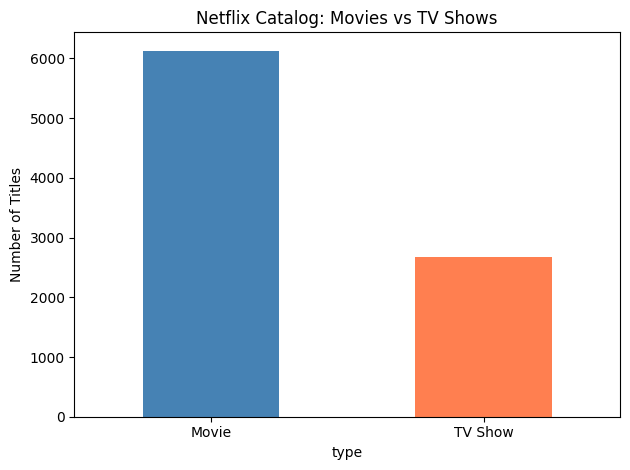

In [4]:
type_counts = df["type"].value_counts()
type_pct = (type_counts / len(df) * 100).round(1)

print(pd.DataFrame({"titles": type_counts, "percent": type_pct}))

type_counts.plot(kind="bar", title="Netflix Catalog: Movies vs TV Shows",
                 color=["steelblue", "coral"])
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The catalog is weighted toward movies, though TV
represents a substantial share - and the growth analysis below shows the mix
has been shifting.

## 4. Catalog growth over time

How many titles was Netflix adding each year - and was it adding movies and
TV shows at the same pace?

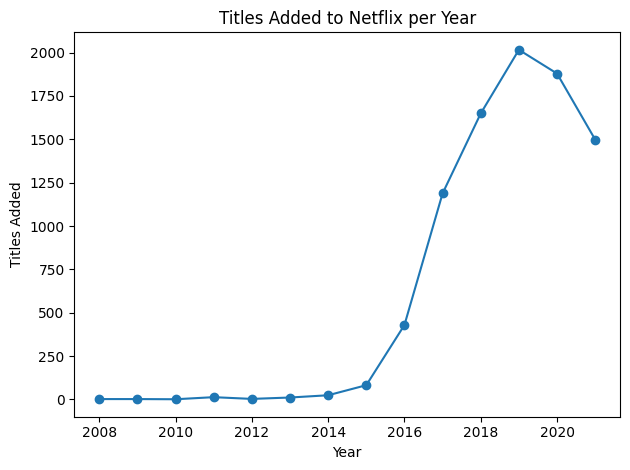

In [5]:
per_year = df["year_added"].value_counts().sort_index()

per_year.plot(kind="line", marker="o", title="Titles Added to Netflix per Year")
plt.ylabel("Titles Added")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

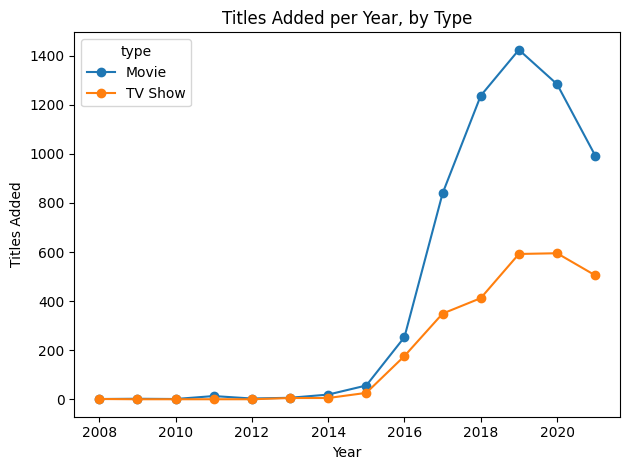

In [6]:
# Split the growth by content type: two lines on one chart.
by_type = pd.crosstab(df["year_added"], df["type"])

by_type.plot(kind="line", marker="o", title="Titles Added per Year, by Type")
plt.ylabel("Titles Added")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

**Observation:** The catalog grew slowly until the mid-2010s, then
expanded sharply. The by-type view shows whether recent investment leans
toward films or series - a strategic signal about where Netflix is placing
its bets.

## 5. Which countries produce Netflix content?

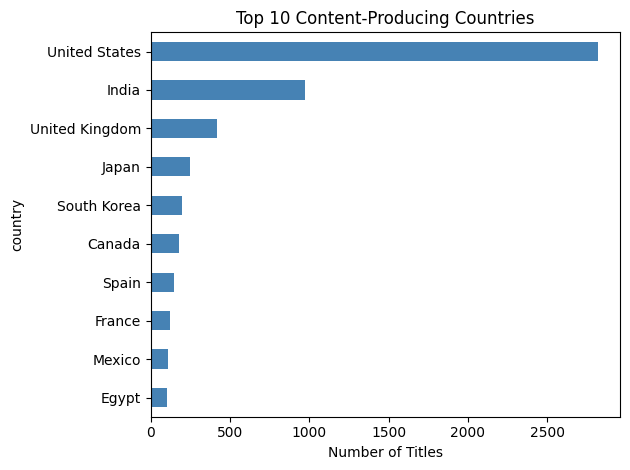

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [7]:
top_countries = df["country"].value_counts().head(10)

top_countries.sort_values().plot(kind="barh",
    title="Top 10 Content-Producing Countries", color="steelblue")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

top_countries

**Data caveat:** some titles list multiple countries in one field (e.g.
"United States, United Kingdom"); this count treats each combination as its
own entry. It is sufficient for identifying the dominant producers, but a
production-credit-level analysis would split these entries first.

## 6. Which genres dominate?

The `listed_in` column packs multiple genres into one cell
("Dramas, International Movies"). Counting the raw cells would treat each
combination as a separate genre, so I split the field and count individual
genres.

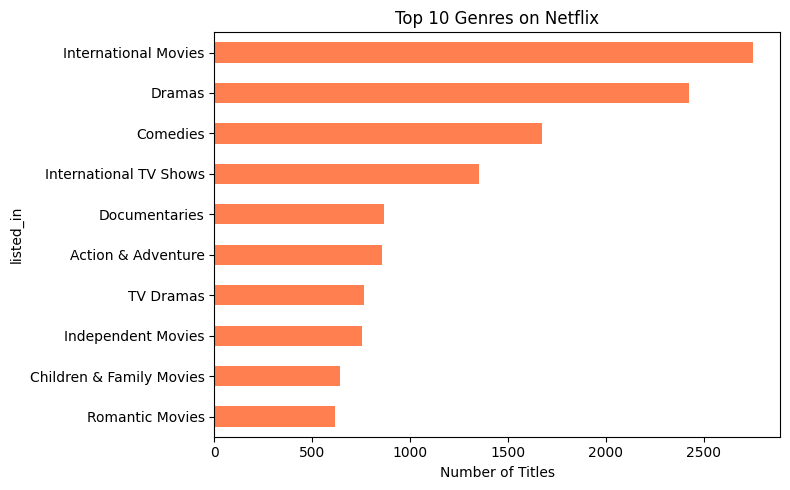

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [8]:
# Split multi-genre cells and give each genre its own row before counting.
genres = df["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)
top_genres.sort_values().plot(kind="barh", figsize=(8, 5),
    title="Top 10 Genres on Netflix", color="coral")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

top_genres

**Observation:** International content and dramas dominate - consistent
with Netflix's global-audience strategy rather than a US-only focus.

## 7. Who is the content aimed at?

The maturity-rating mix indicates the primary target audience.

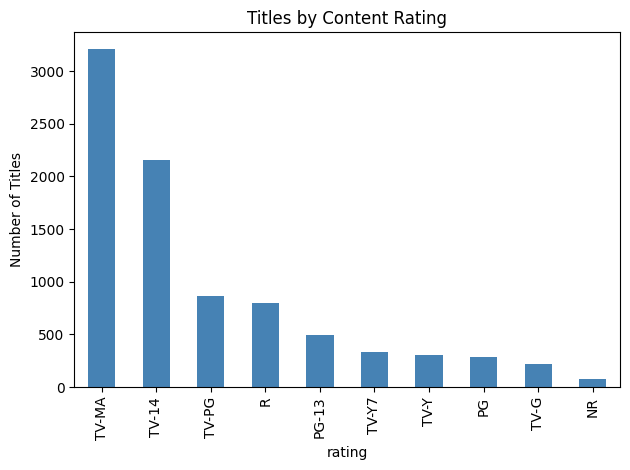

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [9]:
rating_counts = df["rating"].value_counts().head(10)

rating_counts.plot(kind="bar", title="Titles by Content Rating", color="steelblue")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

rating_counts

**Observation:** Mature ratings (TV-MA, TV-14) account for the majority
of the catalog - Netflix's library skews clearly toward adult and teen
audiences rather than family programming.

## 8. How long is typical content?

The `duration` column mixes two units: minutes for movies ("90 min") and
seasons for TV shows ("3 Seasons"). I analyze each type separately.

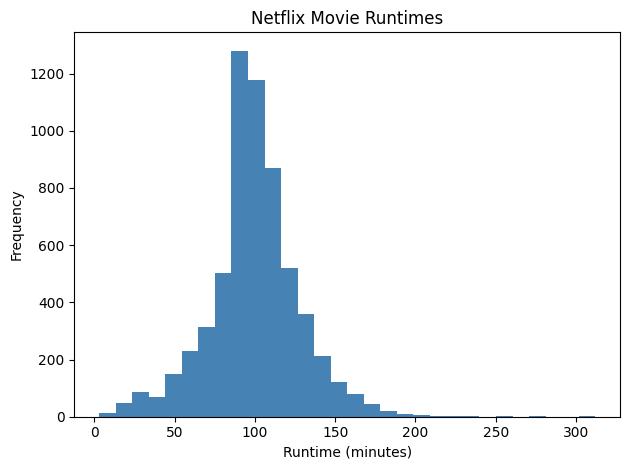

Average movie runtime: 100 minutes
Shortest: 3 min | Longest: 312 min


In [10]:
# Movie runtimes: filter to movies, strip the unit text, convert to numbers.
movies = df[df["type"] == "Movie"].copy()
movies["minutes"] = pd.to_numeric(
    movies["duration"].str.replace(" min", "", regex=False), errors="coerce"
)

movies["minutes"].plot(kind="hist", bins=30, title="Netflix Movie Runtimes", color="steelblue")
plt.xlabel("Runtime (minutes)")
plt.tight_layout()
plt.show()

print(f"Average movie runtime: {movies['minutes'].mean():.0f} minutes")
print(f"Shortest: {movies['minutes'].min():.0f} min | Longest: {movies['minutes'].max():.0f} min")

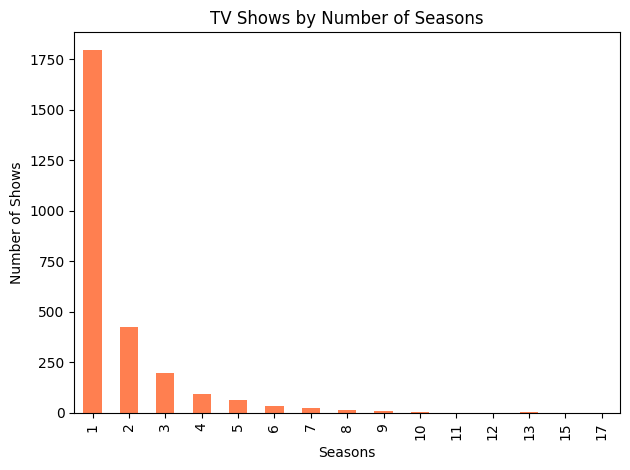

67% of Netflix TV shows have exactly 1 season.


In [11]:
# TV show lengths: strip both " Seasons" and " Season" before converting.
tv = df[df["type"] == "TV Show"].copy()
tv["seasons"] = pd.to_numeric(
    tv["duration"].str.replace(" Seasons", "", regex=False)
                  .str.replace(" Season", "", regex=False),
    errors="coerce"
)

season_counts = tv["seasons"].value_counts().sort_index()
season_counts.plot(kind="bar", title="TV Shows by Number of Seasons", color="coral")
plt.ylabel("Number of Shows")
plt.xlabel("Seasons")
plt.tight_layout()
plt.show()

one_season_pct = (tv["seasons"] == 1).mean() * 100
print(f"{one_season_pct:.0f}% of Netflix TV shows have exactly 1 season.")

**Observation:** Most movies cluster around the standard feature length,
and a striking share of TV shows have only one season - consistent with a
strategy of testing many series and renewing few.

## Key Findings

1. **The catalog is 69.6% Movies and 30.4% TV Shows** (8,807 titles total).

2. **Growth was explosive in the late 2010s.** Titles added per year rose
   from 82 in 2015 to a peak of 2,016 in 2019.

3. **Content production is globally distributed but US-led.** The top
   producers are the United States, India, and the United Kingdom.

4. **International content and Dramas are the largest genres**, reflecting
   a global-audience strategy.

5. **The catalog targets mature audiences**: TV-MA and TV-14 alone account
   for roughly 61% of all titles.

6. **The average movie runs 100 minutes**, and **67% of TV shows have
   just one season** – suggesting Netflix greenlights many series but renews
   selectively.

## What a follow-up analysis would need

This is a *descriptive* analysis of what the catalog contains. The natural
next questions – which content people actually watch, which genres drive
subscriptions, which one-season shows deserved renewal – require viewing
data that is not in this dataset. Pairing this catalog data with engagement
metrics would be the logical next step.

---
*Analysis performed with Python (pandas, matplotlib). Dataset: Netflix
Movies and TV Shows (Kaggle).*